In [1177]:
import numpy as np
import pandas as pd

train_df=pd.read_csv('datasets/playground-series-s5e3/train.csv')
test_df=pd.read_csv('datasets/playground-series-s5e3/test.csv')

In [1]:
# train_df.info()
# train_df.head()
# train_df.describe()
# train_df.isna().sum()

In [1179]:
def preprocess_data(df):
    # contemplating whether to utilize or drop 'day'
    df=df.rename(columns={'temparature': 'temperature'})
    return df

test_ids = test_df['id'].copy()

train_df=preprocess_data(train_df)
test_df=preprocess_data(test_df)

train_df = train_df.drop(columns=['id'], errors='ignore')

In [1180]:
import seaborn as sns
import matplotlib.pyplot as plt

cols=['pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed']
# for col in cols:
#     sns.histplot(train_df[col], kde=True) 
#     plt.title(f'Histplot - {col}')
#     plt.show()

#     sns.boxplot(train_df[col]) 
#     plt.title(f'Boxplot - {col}')
#     plt.show()

In [1181]:
for col in cols:
    # Train Data
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    train_df[f'{col}_capped'] = train_df[col].clip(lower=lower_bound, upper=upper_bound)

    # Test Data
    Q1 = test_df[col].quantile(0.25)
    Q3 = test_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    test_df[f'{col}_capped'] = test_df[col].clip(lower=lower_bound, upper=upper_bound)

In [1182]:
# for col in cols:
#     if f'{col}_capped' in train_df.columns:
#         sns.boxplot(train_df[f'{col}_capped']) 
#         plt.title(f'Boxplot - {col}_capped')
#         plt.show()

In [1183]:
# pressure - max outliers
# maxtemp - left-skewed
# temperature - left-skewed
# mintemp - left-skewed, min outlier
# dewpoint - left-skewed, severe min outliers
# humidity - left-skewed, severe min outliers
# cloud - left-skewed, severe min outliers
# sunshine - right-skewed
# winddirection - bimodal
# windspeed - right-skewed, max outliers

# left-skewed - dewpoint, cloud
# right-skewed - windspeed(sqrt)

from scipy.stats import skew
for col in cols:
    skewness=skew(train_df[col])
    # print(f'Skewness[{col}]: {skewness}')

In [1184]:
left_skewed_cols=['dewpoint', 'cloud']
for col in left_skewed_cols:
    reflected=train_df[col].max() + 1 - train_df[col] # reflect to make right-skewed
    log_transformed=np.log1p(reflected) # apply log transformation
    train_df[f'{col}_log'] = log_transformed.max() + 1 - log_transformed # reflect back to original orientation

    reflected=test_df[col].max() + 1 - test_df[col]
    log_transformed=np.log1p(reflected)
    test_df[f'{col}_log'] = log_transformed.max() + 1 - log_transformed

train_df[f'windspeed_sqrt']=np.sqrt(train_df['windspeed'])
test_df[f'windspeed_sqrt']=np.sqrt(test_df['windspeed'])

In [1185]:
# log_transformed=['dewpoint_log', 'cloud_log']
# sqrt_transformed=['windspeed_sqrt']

# for col in log_transformed:
#     sns.histplot(train_df[col]) 
#     plt.title(f'Histplot - {col}')
#     plt.show()

# for col in sqrt_transformed:
#     sns.histplot(train_df[col]) 
#     plt.title(f'Histplot - {col}')
#     plt.show()

In [1186]:
train_df.columns

Index(['day', 'pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed',
       'rainfall', 'pressure_capped', 'maxtemp_capped', 'temperature_capped',
       'mintemp_capped', 'dewpoint_capped', 'humidity_capped', 'cloud_capped',
       'sunshine_capped', 'winddirection_capped', 'windspeed_capped',
       'dewpoint_log', 'cloud_log', 'windspeed_sqrt'],
      dtype='object')

In [1187]:
# pressure
# sunshine
# dewpoint
# humidity
# cloud
# NN - Scatterplot
# CN - Boxplot
# CC - Grouped Barplot

# sns.barplot(train_df, x='rainfall', y='pressure')
# plt.title('Rainfall : Pressure')
# plt.xlabel('Rainfall')
# plt.ylabel('Pressure')
# plt.tight_layout()
# plt.show()

# def remove_redundant_features(df):
#     df=df.drop(columns=['pressure', 'mintemp', 'dewpoint', 'dewpoint_log', 'humidity', 'windspeed', 'windspeed_sqrt', 'cloud', 'cloud_log', 'maxtemp'])
#     return df

# train_df=remove_redundant_features(train_df)
# test_df=remove_redundant_features(test_df)

# corr_matrix = train_df.corr(numeric_only=True)
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
# plt.title('Correlation Heatmap of All Numeric Features')
# plt.tight_layout()
# plt.show()

In [1188]:
# CORRELATIONS
# windspeed_capped = windspeed (1.00)
# windspeed_sqrt = windspeed (0.99)
# windspeed_sqrt = windspeed_capped (0.99)
# cloud_log = cloud (0.91)
# dewpoint_log = dewpoint_capped (0.96)

# mintemp_capped = temperature (0.99)
# temperature = maxtemp (0.98)
# mintemp_capped = maxtemp (0.97)
# dewpoint_capped = temperature (0.94)
# dewpoint_log = mintemp_capped (0.93)
# dewpoint_capped/log = maxtemp (0.91)

# pressure_capped != maxtemp (-0.80)
# pressure_capped != temperature (-0.82)
# cloud_capped != sunshine (-0.83)
# dewpoint_log != pressure_capped (-0.83)

# DECISIONS
# Keep one windspeed - use capped
# Keep one cloud - use log
# Keep one dewpoint - use log

In [1189]:
# plt.figure(figsize=(4, 4))
# sns.scatterplot(data=train_df, x='mintemp_capped', y='temperature')
# plt.title('mintemp_capped vs. temperature')
# plt.xlabel('mintemp_capped')
# plt.ylabel('temperature')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(4, 4))
# sns.scatterplot(data=train_df, x='temperature', y='maxtemp')
# plt.title('temperature vs. maxtemp')
# plt.xlabel('temperature')
# plt.ylabel('maxtemp')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(4, 4))
# sns.scatterplot(data=train_df, x='mintemp_capped', y='maxtemp')
# plt.title('mintemp_capped vs. maxtemp')
# plt.xlabel('mintemp_capped')
# plt.ylabel('maxtemp')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(4, 4))
# sns.scatterplot(data=train_df, x='dewpoint_log', y='temperature')
# plt.title('dewpoint_log vs. temperature')
# plt.xlabel('dewpoint_log')
# plt.ylabel('temperature')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(4, 4))
# sns.scatterplot(data=train_df, x='dewpoint_log', y='mintemp_capped')
# plt.title('dewpoint_log vs. mintemp_capped')
# plt.xlabel('dewpoint_log')
# plt.ylabel('mintemp_capped')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(4, 4))
# sns.scatterplot(data=train_df, x='dewpoint_log', y='maxtemp')
# plt.title('dewpoint_log vs. maxtemp')
# plt.xlabel('dewpoint_log')
# plt.ylabel('maxtemp')
# plt.tight_layout()
# plt.show()

In [1190]:
print(y.value_counts())

rainfall
1    1650
0     540
Name: count, dtype: int64


In [1191]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

X=train_df.drop(columns=['rainfall'])
y=train_df['rainfall']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

pipeline=Pipeline([
('rf', RandomForestClassifier(
    class_weight=None,
    criterion='gini',
    max_depth=3,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
))
])

pipeline.fit(X_train, y_train)

probs=pipeline.predict_proba(X_test)[:, 1]

threshold = 0.4
predictions = (probs >= threshold).astype(int)

# predictions=grid_search.predict(X_test)

accuracy=accuracy_score(y_test, predictions)

In [1192]:
grid_search.best_params_

{'rf__class_weight': None,
 'rf__criterion': 'gini',
 'rf__max_depth': 3,
 'rf__max_features': 'sqrt',
 'rf__min_samples_leaf': 4,
 'rf__min_samples_split': 2,
 'rf__n_estimators': 200}

[ ACCURACY ]


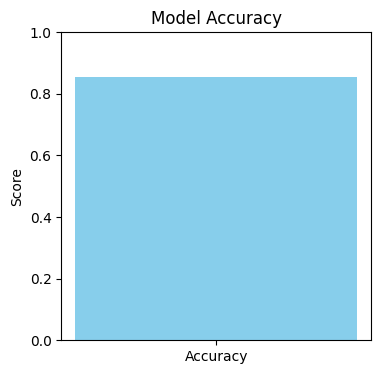

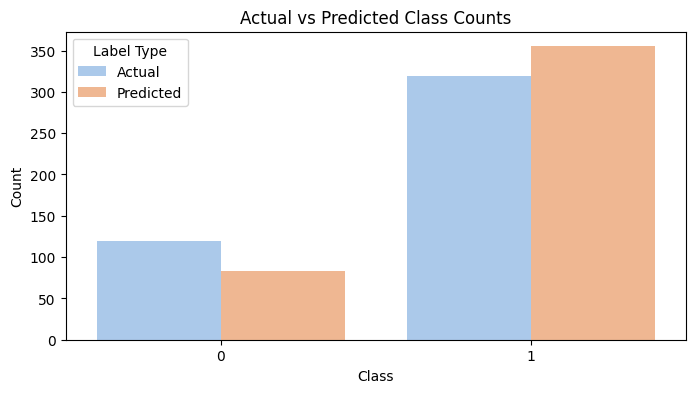

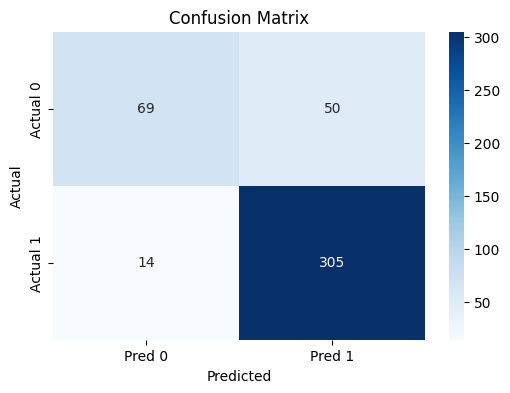

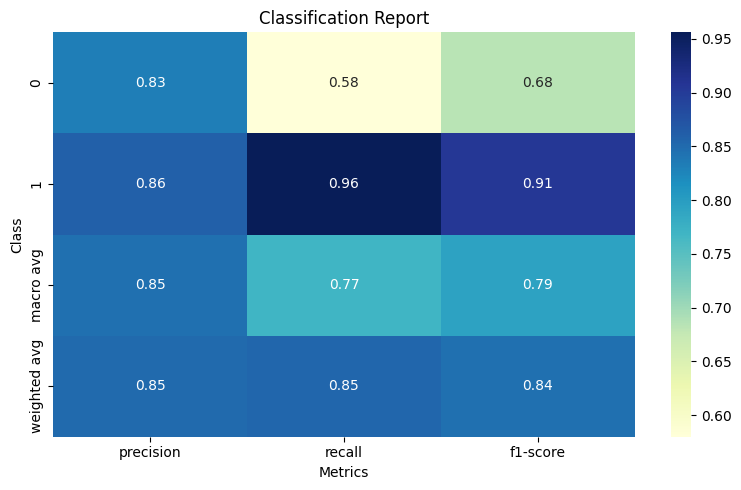

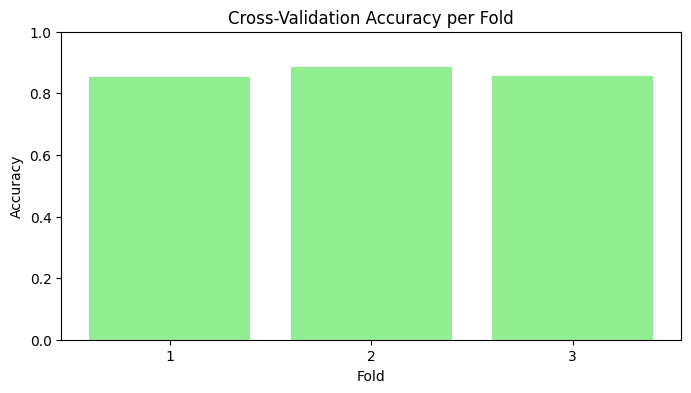

In [1193]:
# 1. Accuracy - Bar Plot
print("[ ACCURACY ]")
plt.figure(figsize=(4, 4))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

# 2. Actual vs Predicted - Bar Chart
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

plt.figure(figsize=(8, 4))
sns.countplot(
    x='value', hue='Type',
    data=pd.melt(results_df, value_vars=['Actual', 'Predicted'], var_name='Type'),
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Precision, Recall, F1 Score - Heatmap
report = classification_report(y_test, predictions, output_dict=True, zero_division=0)

# Convert to DataFrame (remove 'accuracy' to keep it 2D for heatmap)
report_df = pd.DataFrame(report).drop(columns=['accuracy'])
plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:3, :].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot
scores = cross_val_score(pipeline, X, y, cv=3)
plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 4))
plt.show()

In [1194]:
import joblib

# Keep 'id' separately before preprocessing
test_ids = test_df['id'].copy()

# Prepare test data (drop id after saving it)
X_final_test = test_df.drop(columns=['id'], errors='ignore')

# Predict probabilities using the trained pipeline
test_probs = pipeline.predict_proba(X_final_test)[:, 1]

# Apply your threshold
threshold = 0.4
test_predictions = (test_probs >= threshold).astype(int)

# Create submission DataFrame using saved IDs
submission = pd.DataFrame({
    'id': test_ids,
    'rainfall': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)